# Animal Classification Using CNN

**Assignment Type:** Multi-Class Classification  
**Number of Classes:** 5  
**Classes:** Cat, Cow, Deer, Dog, Lion



In [2]:
import os
import zipfile
import shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report

print("TensorFlow version:", tf.__version__)
print("GPU available:", len(tf.config.list_physical_devices("GPU")) > 0)

TensorFlow version: 2.20.0
GPU available: False


In [3]:
# This notebook was prepared for the uploaded dataset:
# archive (4).zip

zip_candidates = [
    "/content/archive (4).zip",
    "/mnt/data/archive (4).zip"
]

zip_path = next((p for p in zip_candidates if os.path.exists(p)), None)

# If the notebook is opened in Colab and the ZIP is not already present,
# upload it automatically.
if zip_path is None:
    from google.colab import files
    print("Please upload the dataset ZIP file.")
    uploaded = files.upload()
    uploaded_name = next(iter(uploaded))
    zip_path = os.path.join("/content", uploaded_name)

extract_path = "/content/animal_dataset"

if os.path.exists(extract_path):
    shutil.rmtree(extract_path)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

dataset_path = os.path.join(extract_path, "animals_dataset")

print("ZIP:", zip_path)
print("Dataset:", dataset_path)
print("Dataset extracted successfully.")

Please upload the dataset ZIP file.


Saving archive (4).zip to archive (4).zip
ZIP: /content/archive (4).zip
Dataset: /content/animal_dataset/animals_dataset
Dataset extracted successfully.


In [4]:
expected_splits = ["train", "validation", "test"]
expected_classes = ["cat", "cow", "deep", "dog", "lion"]

for split in expected_splits:
    split_path = os.path.join(dataset_path, split)
    print(f"\n{split.upper()}")

    total = 0
    for class_name in expected_classes:
        class_path = os.path.join(split_path, class_name)
        count = 0

        if os.path.isdir(class_path):
            count = sum(
                1 for f in os.listdir(class_path)
                if f.lower().endswith((".jpg", ".jpeg", ".png"))
            )

        print(f"  {class_name}: {count}")
        total += count

    print("  Total:", total)


TRAIN
  cat: 91
  cow: 86
  deep: 87
  dog: 111
  lion: 89
  Total: 464

VALIDATION
  cat: 17
  cow: 15
  deep: 17
  dog: 17
  lion: 17
  Total: 83

TEST
  cat: 17
  cow: 16
  deep: 16
  dog: 16
  lion: 17
  Total: 82


In [5]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
EPOCHS = 30
NUM_CLASSES = 5

display_names = ["Cat", "Cow", "Deer", "Dog", "Lion"]

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Epochs:", EPOCHS)
print("Classes:", display_names)

Image size: (128, 128)
Batch size: 32
Epochs: 30
Classes: ['Cat', 'Cow', 'Deer', 'Dog', 'Lion']


In [6]:
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode="nearest"
)

validation_datagen = ImageDataGenerator(
    rescale=1.0 / 255
)

test_datagen = ImageDataGenerator(
    rescale=1.0 / 255
)

print("Preprocessing and augmentation configured.")

Preprocessing and augmentation configured.


In [7]:
train_generator = train_datagen.flow_from_directory(
    os.path.join(dataset_path, "train"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
    seed=42
)

validation_generator = validation_datagen.flow_from_directory(
    os.path.join(dataset_path, "validation"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    os.path.join(dataset_path, "test"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

print("\nClass indices:", train_generator.class_indices)

Found 464 images belonging to 5 classes.
Found 83 images belonging to 5 classes.
Found 82 images belonging to 5 classes.

Class indices: {'cat': 0, 'cow': 1, 'deep': 2, 'dog': 3, 'lion': 4}


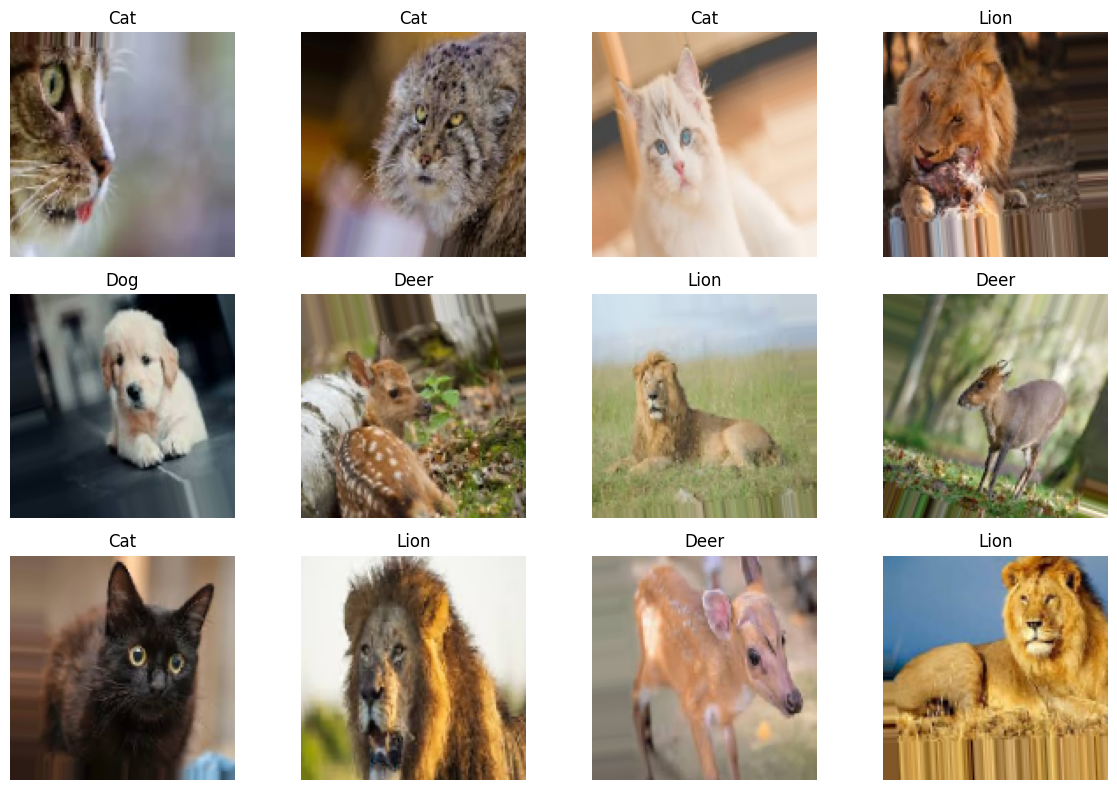

In [8]:
images, labels = next(train_generator)

plt.figure(figsize=(12, 8))

for i in range(min(12, len(images))):
    plt.subplot(3, 4, i + 1)
    plt.imshow(images[i])

    original_index = np.argmax(labels[i])
    original_class = list(train_generator.class_indices.keys())[original_index]

    label_map = {
        "cat": "Cat",
        "cow": "Cow",
        "deep": "Deer",
        "dog": "Dog",
        "lion": "Lion"
    }

    plt.title(label_map.get(original_class, original_class))
    plt.axis("off")

plt.tight_layout()
plt.show()

In [9]:
model = models.Sequential([
    layers.Input(shape=(128, 128, 3)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(NUM_CLASSES, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 831,429 (3.17 MB)

 Trainable params: 831,429 (3.17 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [11]:
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=validation_generator
)

Epoch 1/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 12s 718ms/step - accuracy: 0.1897 - loss: 1.6276 - val_accuracy: 0.2048 - val_loss: 1.6100
Epoch 2/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 684ms/step - accuracy: 0.2328 - loss: 1.6025 - val_accuracy: 0.2048 - val_loss: 1.6057
Epoch 3/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 681ms/step - accuracy: 0.2198 - loss: 1.5861 - val_accuracy: 0.1807 - val_loss: 1.6992
Epoch 4/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 712ms/step - accuracy: 0.2629 - loss: 1.5884 - val_accuracy: 0.2169 - val_loss: 1.5969
Epoch 5/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 752ms/step - accuracy: 0.2866 - loss: 1.5599 - val_accuracy: 0.2530 - val_loss: 1.5591
Epoch 6/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 723ms/step - accuracy: 0.2888 - loss: 1.5452 - val_accuracy: 0.2771 - val_loss: 1.5292
Epoch 7/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 720ms/step - accuracy: 0.3534 - loss: 1.5152 - val_accuracy: 0.2892 - val_loss: 1.5427
Epoch 8/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 710ms/step - accuracy: 0.3362 - loss: 1.4961 - val_accu

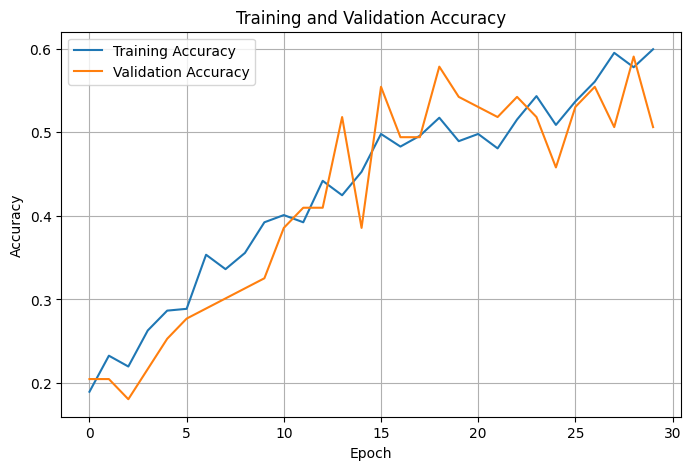

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

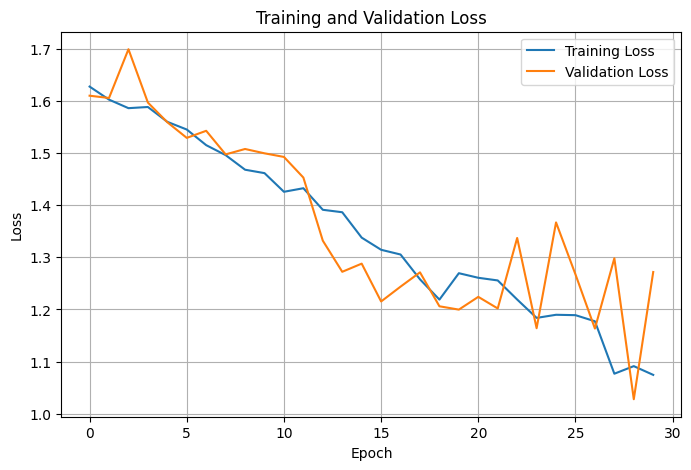

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [14]:
test_loss, test_accuracy = model.evaluate(test_generator, verbose=1)

print("\nTest Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_accuracy, 4))
print("Test Accuracy Percentage:", round(test_accuracy * 100, 2), "%")

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 144ms/step - accuracy: 0.5000 - loss: 1.1763

Test Loss: 1.1763
Test Accuracy: 0.5
Test Accuracy Percentage: 50.0 %


In [15]:
test_generator.reset()

prediction_probabilities = model.predict(test_generator, verbose=1)
predicted_classes = np.argmax(prediction_probabilities, axis=1)
true_classes = test_generator.classes

print("Predictions generated.")

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 168ms/step
Predictions generated.


In [16]:
folder_to_display = {
    "cat": "Cat",
    "cow": "Cow",
    "deep": "Deer",
    "dog": "Dog",
    "lion": "Lion"
}

folder_class_names = list(test_generator.class_indices.keys())
report_names = [folder_to_display.get(name, name) for name in folder_class_names]

print(classification_report(
    true_classes,
    predicted_classes,
    target_names=report_names,
    zero_division=0
))

              precision    recall  f1-score   support

         Cat       0.43      0.76      0.55        17
         Cow       0.50      0.69      0.58        16
        Deer       0.75      0.38      0.50        16
         Dog       0.30      0.19      0.23        16
        Lion       0.67      0.47      0.55        17

    accuracy                           0.50        82
   macro avg       0.53      0.50      0.48        82
weighted avg       0.53      0.50      0.48        82



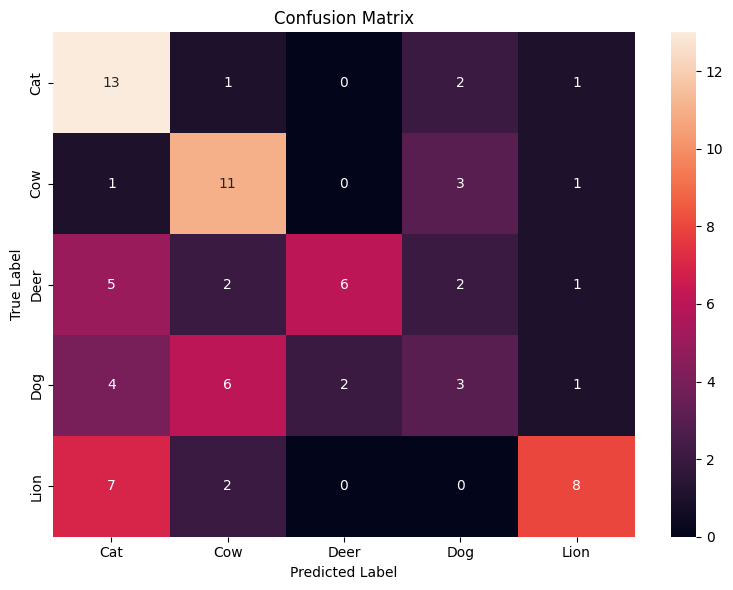

In [17]:
cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=report_names,
    yticklabels=report_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

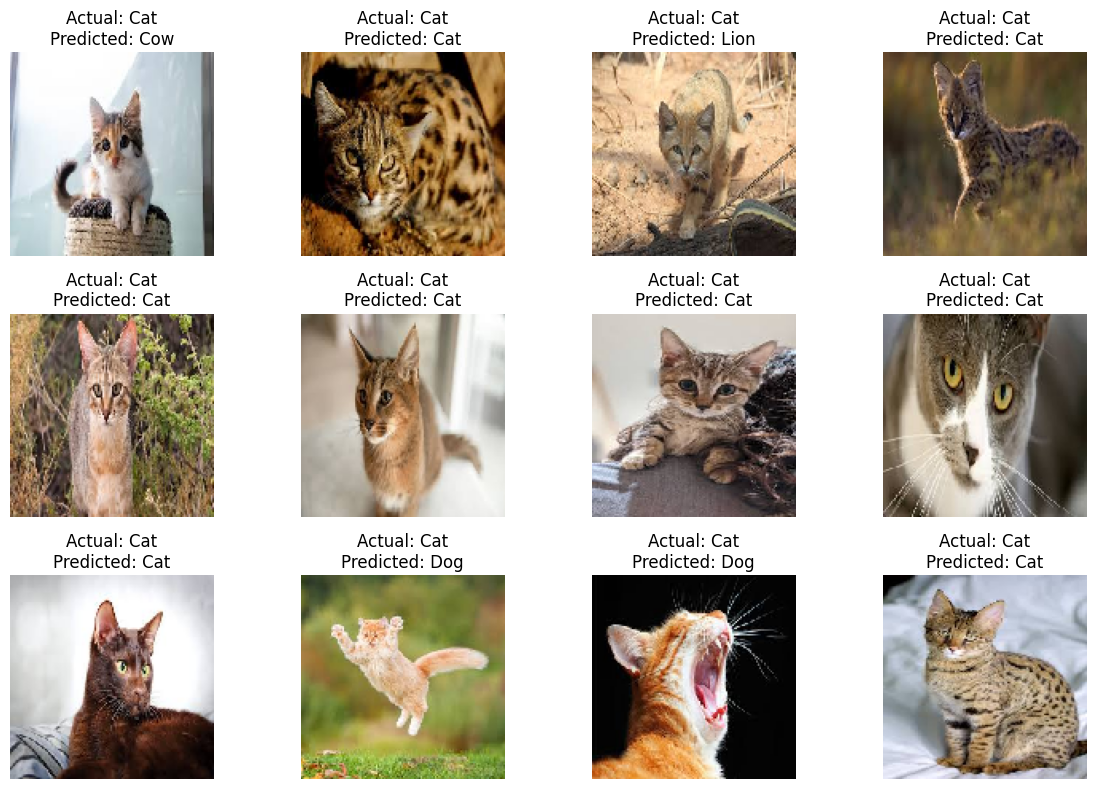

In [18]:
test_generator.reset()
test_images, test_labels = next(test_generator)

plt.figure(figsize=(12, 8))

for i in range(min(12, len(test_images))):
    plt.subplot(3, 4, i + 1)

    image = test_images[i]
    prediction = model.predict(np.expand_dims(image, axis=0), verbose=0)[0]

    predicted_index = np.argmax(prediction)
    actual_index = np.argmax(test_labels[i])

    predicted_label = report_names[predicted_index]
    actual_label = report_names[actual_index]

    plt.imshow(image)
    plt.title(
        f"Actual: {actual_label}\nPredicted: {predicted_label}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

Upload an animal image to test the CNN.


Saving download (1).jpeg to download (1).jpeg


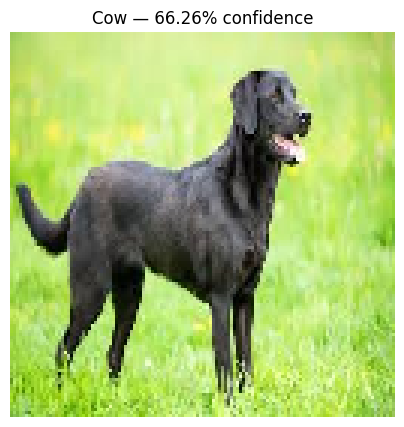

Predicted Animal: Cow
Confidence: 66.26%


In [19]:
try:
    from google.colab import files

    print("Upload an animal image to test the CNN.")
    uploaded = files.upload()

    for filename in uploaded.keys():
        from tensorflow.keras.utils import load_img, img_to_array

        img = load_img(filename, target_size=IMG_SIZE)
        img_array = img_to_array(img) / 255.0
        img_array = np.expand_dims(img_array, axis=0)

        prediction = model.predict(img_array, verbose=0)[0]
        predicted_index = np.argmax(prediction)
        predicted_label = report_names[predicted_index]
        confidence = prediction[predicted_index] * 100

        plt.figure(figsize=(5, 5))
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"{predicted_label} — {confidence:.2f}% confidence")
        plt.show()

        print("Predicted Animal:", predicted_label)
        print("Confidence:", f"{confidence:.2f}%")

except ImportError:
    print("This cell is intended to be run in Google Colab.")

In [22]:
model_save_path = "/content/animal_classification_cnn.keras"
model.save(model_save_path)

print("Model saved to:", model_save_path)

Model saved to: /content/animal_classification_cnn.keras
